<a href="https://colab.research.google.com/github/SmitaBhalerao56/Customer_Churn_Analysis_Feature/blob/main/Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv('/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
conn=sqlite3.connect('churn.db')

In [4]:
df.to_sql('customer_churn',conn,if_exists='replace', index=False)

7043

In [8]:
query = "SELECT count(*) FROM customer_churn"
pd.read_sql(query, conn)

,count(*)
0,7043


In [11]:
query='''
SELECT COUNT(*)
FROM customer_churn
WHERE TotalCharges IS NULL OR TotalCharges = ' '
'''
pd.read_sql(query,conn)

,COUNT(*)
0,11


In [12]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df.to_sql('customer_churn',conn,if_exists='replace',index=False)

7043

In [18]:
query='select churn,count(*) from customer_churn group by churn'
pd.read_sql(query,conn)

,Churn,count(*)
0,No,5174
1,Yes,1869


In [30]:
query="""
select Contract,
count(*) as Total_Customers,
sum(case when churn= 'Yes' then 1 else 0 end) as churned_customers
from customer_churn Group BY Contract
"""
pd.read_sql(query, conn)

,Contract,Total_Customers,churned_customers
0,Month-to-month,3875,1655
1,One year,1473,166
2,Two year,1695,48


In [31]:
query = """
SELECT Churn, AVG(MonthlyCharges) AS avg_monthly_charges
FROM customer_churn
GROUP BY Churn
"""
pd.read_sql(query, conn)

,Churn,avg_monthly_charges
0,No,61.265124
1,Yes,74.441332


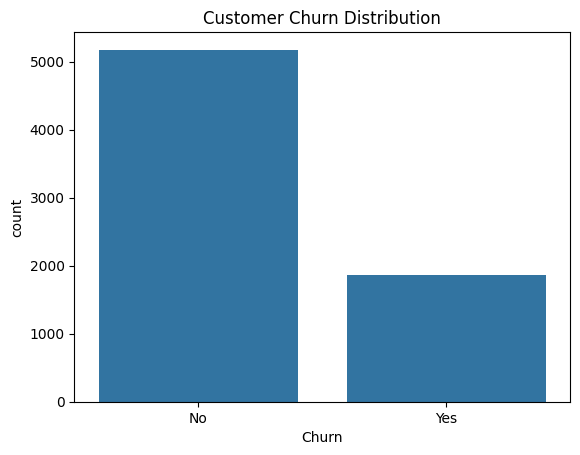

In [32]:
sns.countplot(x='Churn', data=df)
plt.title('Customer Churn Distribution')
plt.show()

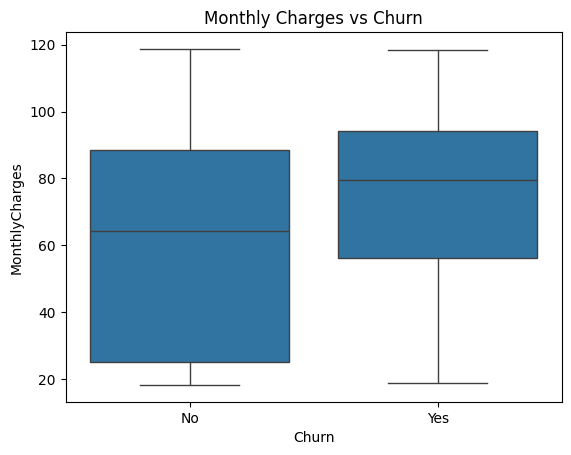

In [33]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()


In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()